In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1429_1.csv to 1429_1.csv


In [ ]:
df = pd.read_csv("1429_1.csv", low_memory=False)
print (df)

                         id  \
0      AVqkIhwDv8e3D1O-lebb   
1      AVqkIhwDv8e3D1O-lebb   
2      AVqkIhwDv8e3D1O-lebb   
3      AVqkIhwDv8e3D1O-lebb   
4      AVqkIhwDv8e3D1O-lebb   
...                     ...   
34655  AVpfiBlyLJeJML43-4Tp   
34656  AVpfiBlyLJeJML43-4Tp   
34657  AVpfiBlyLJeJML43-4Tp   
34658  AVpfiBlyLJeJML43-4Tp   
34659  AVpfiBlyLJeJML43-4Tp   

                                                    name       asins   brand  \
0      All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
1      All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
2      All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
3      All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
4      All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
...                                                  ...         ...     ...   
34655                                                NaN  B006GWO5W

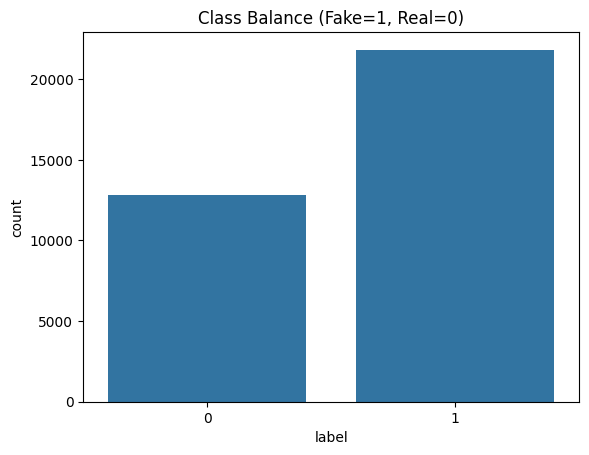

In [ ]:
df.drop(columns=[
    'reviews.didPurchase', 'reviews.id', 'reviews.userCity',
    'reviews.userProvince', 'reviews.dateAdded', 'reviews.dateSeen',
    'reviews.sourceURLs', 'asins', 'reviews.id'
], errors='ignore', inplace=True)

# Drop rows where main text is missing
df.dropna(subset=['reviews.text'], inplace=True)

# Fill remaining missing values
df['reviews.numHelpful'] = df['reviews.numHelpful'].fillna(0)
df['reviews.doRecommend'] = df['reviews.doRecommend'].fillna(df['reviews.doRecommend'].mode()[0])
df['reviews.rating'] = df['reviews.rating'].fillna(df['reviews.rating'].median())
df['reviews.title'] = df['reviews.title'].fillna('')
df['name'] = df['name'].fillna('Unknown')
df['brand'] = df['brand'].fillna('Unknown')
df['manufacturer'] = df['manufacturer'].fillna('Unknown')

# Add text length feature
df['text_length'] = df['reviews.text'].apply(len)

# Clean text
def clean_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    text = text.strip() # Remove leading/trailing whitespace
    return text

df['clean_text'] = df['reviews.text'].apply(clean_text)


# Heuristic labeling
df['label'] = (
    ((df['reviews.rating'] == 5) & (df['reviews.numHelpful'] == 0)) |
    (df['text_length'] < 40)
).astype(int)

# Check class distribution
sns.countplot(x='label', data=df)
plt.title("Class Balance (Fake=1, Real=0)")
plt.show()

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF (use same one)
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Chi-square test
chi2_scores, p_values = chi2(X_tfidf, y)

# Display top 20 significant words
feature_names = tfidf.get_feature_names_out()
top_indices = chi2_scores.argsort()[-20:][::-1]

print("Top 20 words most correlated with label (Chi-square):")
for i in top_indices:
    print(f"{feature_names[i]}: Score={chi2_scores[i]:.2f}, p-value={p_values[i]:.4f}")

Top 20 words most correlated with label (Chi-square):
not: Score=152.89, p-value=0.0000
but: Score=143.96, p-value=0.0000
slow: Score=121.97, p-value=0.0000
love: Score=101.56, p-value=0.0000
only: Score=77.71, p-value=0.0000
good: Score=77.34, p-value=0.0000
google: Score=69.70, p-value=0.0000
ok: Score=67.44, p-value=0.0000
ads: Score=49.93, p-value=0.0000
that: Score=46.56, p-value=0.0000
tablet: Score=46.22, p-value=0.0000
doesnt: Score=45.97, p-value=0.0000
sometimes: Score=45.49, p-value=0.0000
be: Score=43.85, p-value=0.0000
wish: Score=41.42, p-value=0.0000
decent: Score=37.76, p-value=0.0000
stars: Score=37.31, p-value=0.0000
overall: Score=37.16, p-value=0.0000
awesome: Score=35.54, p-value=0.0000
limited: Score=35.12, p-value=0.0000


In [ ]:
# Simple text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)      # Remove numbers
    return text

df['clean_text'] = df['reviews.text'].apply(clean_text)

In [ ]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=1000)
X_text = tfidf.fit_transform(df['clean_text'])

# Combine numerical features (optional)
X_extra = df[['reviews.rating', 'reviews.numHelpful', 'text_length']]
from scipy.sparse import hstack
X = hstack([X_text, X_extra])

# Labels
y = df['label']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_tfidf, y)

# Feature importance based on coefficients
feature_names = tfidf.get_feature_names_out()
coefs = np.abs(lr.coef_[0])
top_indices = coefs.argsort()[-20:][::-1]

print("Top 20 important features based on logistic regression coefficients:")
for i in top_indices:
    print(f"{feature_names[i]}: {coefs[i]:.4f}")

Top 20 important features based on logistic regression coefficients:
slow: 4.6253
stars: 3.1819
return: 3.0875
sometimes: 2.9692
difficult: 2.9011
not: 2.7320
returned: 2.6322
love: 2.6020
otherwise: 2.5175
ok: 2.4829
wish: 2.4416
awesome: 2.4335
doesnt: 2.4292
google: 2.4067
but: 2.1865
limited: 2.1561
amazing: 2.1343
echo: 2.0900
except: 2.0470
however: 2.0189


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


=== Logistic Regression ===
Accuracy: 0.999
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2566
           1       1.00      1.00      1.00      4366

    accuracy                           1.00      6932
   macro avg       1.00      1.00      1.00      6932
weighted avg       1.00      1.00      1.00      6932



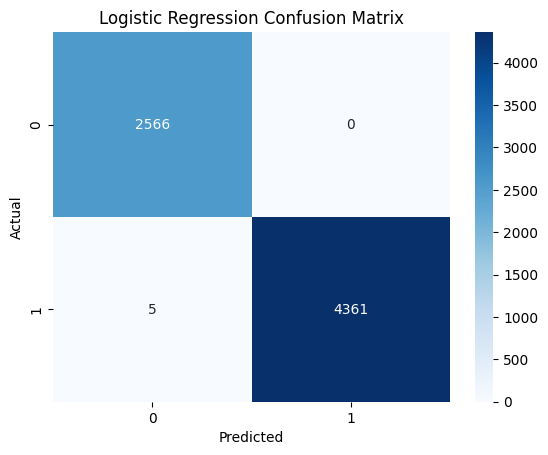


=== Naive Bayes ===
Accuracy: 0.756
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.43      0.57      2566
           1       0.74      0.95      0.83      4366

    accuracy                           0.76      6932
   macro avg       0.78      0.69      0.70      6932
weighted avg       0.77      0.76      0.73      6932



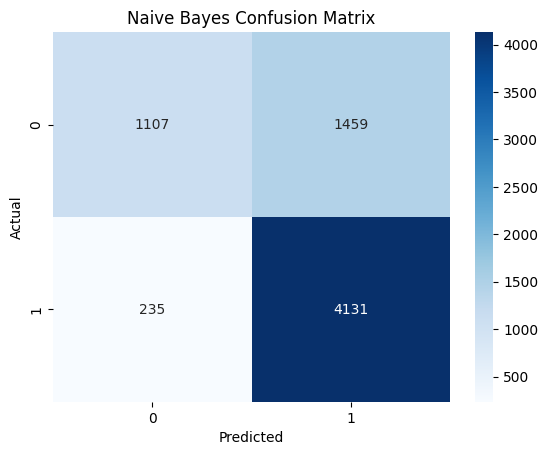


=== Random Forest ===
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2566
           1       1.00      1.00      1.00      4366

    accuracy                           1.00      6932
   macro avg       1.00      1.00      1.00      6932
weighted avg       1.00      1.00      1.00      6932



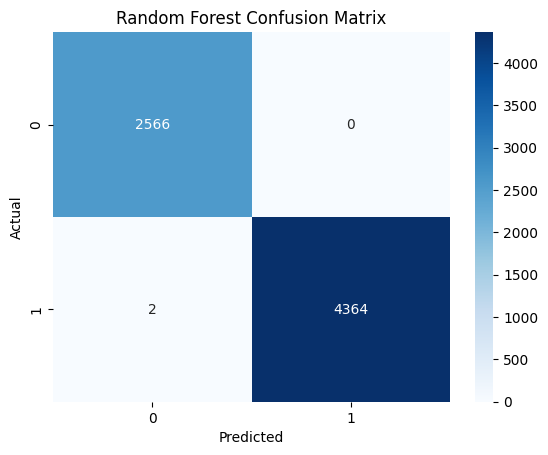

In [ ]:
# Helper function to evaluate
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate all models
from sklearn.metrics import accuracy_score

evaluate_model("Logistic Regression", y_test, log_pred)
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Random Forest", y_test, rf_pred)

In [ ]:
import re
import numpy as np

def predict_fake_review(review_text, rating, num_helpful, model, tfidf_vectorizer):
    clean_text = re.sub(r'[^a-zA-Z\s]', '', review_text.lower())
    tfidf_features = tfidf_vectorizer.transform([clean_text])
    text_length = len(review_text)
    extra_features = [[rating, num_helpful, text_length]]
    combined_features = np.hstack((tfidf_features.toarray(), extra_features))
    prediction = model.predict(combined_features)
    return "Fake Review ❌" if prediction[0] == 1 else "Real Review ✅"

In [ ]:
# Test
review = "This product is awesome! I loved everything about it."
rating = 5
helpful_votes = 0

result = predict_fake_review(review, rating, helpful_votes, rf_model, tfidf)
print("Prediction:", result)

Prediction: Fake Review ❌


In [ ]:
predict_fake_review(
    "I loved this product, very high quality and fast delivery!",
    rating=5,
    num_helpful=0,
    model=rf_model,
    tfidf_vectorizer=tfidf
)
print("Prediction:", result)

Prediction: Fake Review ❌


In [ ]:
predict_fake_review(
    "I received the haircurler band yesterday.It showed that they will provide a claw clip, which I did not get.Anyways, I tried the band, it gave a nice curls.So, I am happy.At least it works! ",
    rating=4,
    num_helpful=35,
    model=rf_model,
    tfidf_vectorizer=tfidf
)
print("Prediction:", result)

Prediction: Fake Review ❌


In [ ]:
# Get prediction probabilities
def predict_with_prob(review_text, rating, num_helpful, model, tfidf_vectorizer):
    import re
    import numpy as np

    clean_text = re.sub(r'[^a-zA-Z\s]', '', review_text.lower())
    tfidf_features = tfidf_vectorizer.transform([clean_text])
    text_length = len(review_text)
    extra_features = [[rating, num_helpful, text_length]]
    combined_features = np.hstack((tfidf_features.toarray(), extra_features))

    prob = model.predict_proba(combined_features)[0][1]
    print(f"Predicted FAKE probability: {prob:.2f}")
    return "Fake ❌" if prob >= 0.5 else "Real ✅"

# Try again
predict_with_prob(
    "I received the haircurler band yesterday. It showed that they will provide a claw clip, which I did not get. Anyways, I tried the band, it gave a nice curls. So, I am happy. At least it works!",
    rating=4,
    num_helpful=35,
    model=rf_model,
    tfidf_vectorizer=tfidf
)

Predicted FAKE probability: 0.05


'Real ✅'

In [ ]:
# Get prediction probabilities
def predict_with_prob(review_text, rating, num_helpful, model, tfidf_vectorizer):
    import re
    import numpy as np

    clean_text = re.sub(r'[^a-zA-Z\s]', '', review_text.lower())
    tfidf_features = tfidf_vectorizer.transform([clean_text])
    text_length = len(review_text)
    extra_features = [[rating, num_helpful, text_length]]
    combined_features = np.hstack((tfidf_features.toarray(), extra_features))

    prob = model.predict_proba(combined_features)[0][1]
    print(f"Predicted FAKE probability: {prob:.2f}")
    return "Fake ❌" if prob >= 0.5 else "Real ✅"

# Try again
predict_with_prob(
    "Nice",
    rating=4,
    num_helpful=2,
    model=rf_model,
    tfidf_vectorizer=tfidf
)

Predicted FAKE probability: 0.61


'Fake ❌'